STARTED:      2/26/25

LAST UPDATED: 3/4/25

By Eugene Fong

# GOAL(S)

- Pseudobulk on the SN data

# #* TODO

XYLENA: 
- pseudobulk each category (young/old) then run w/the tools Adam used
- avg's expression of each cell type in each sample
- should have a tool in scanpy
- also in Adam's pipeline

ADAM
- break up the adata obj into indiv clusters by cell type for the trajectory analysis
- redo the DGE by cell type, 
- use the leiden_2 cluster

Pseudo-bulking = collapsing into counts the mean expression for that sample
- sum is better for genes that are lowly expressed by highly variable betw samples
- mean is better for genes that are highly expressed genes

Lit review on pseudotime and trajectory analysis tools, run by some suggestions by Xylena before starting on one

# CHANGE - choose your cell type:

```
cell_type[0] = DaN
cell_type[1] = ExN
cell_type[2] = EC
cell_type[3] = Oligo
cell_type[4] = Astro
cell_type[5] = OPC
cell_type[6] = PC
cell_type[7] = MG
cell_type[8] = InN
cell_type[9] = TC
```

In [1]:
cell_type_number = 0

# LOAD DATA

### DEFINE PATHS

In [2]:
# INPUT - my mod'ed .h5ad file
input_file = '/vf/users/CARD_singlecell/SN_control_atlas/multiome-pipeline/src/output/05_annotated_anndata_rna-ef-rank_genes_groups.h5ad'

In [3]:
# # OUTPUT - file path for my testing, base on the original file name
# output_file = os.path.join('output', os.path.basename(input_file).replace('.h5ad', '-ef-rank_genes_groups.h5ad'))
# print('output_file =', output_file)

# PSEUDOBULK + DGE

#* TODO

- run Adam's updated rna_DGE.py script in JNB (copy and paste?)
- will need to edit some of the variables
- read up on DESEQ2 and Decouplr

Can figure out how ot pull GH properly laterrrr

### REFS: 

- Adam's DGE snakemake rule
- Pseudo-bulk: [https://decoupler-py.readthedocs.io/en/latest/notebooks/pseudobulk.html](https://decoupler-py.readthedocs.io/en/latest/notebooks/pseudobulk.html)
- DESeq2 (original in R): [https://bioconductor.org/packages/release/bioc/html/DESeq2.html](https://bioconductor.org/packages/release/bioc/html/DESeq2.html)
- PyDESeq2 (Python vers): [https://pydeseq2.readthedocs.io/en/stable/](https://pydeseq2.readthedocs.io/en/stable/)

# INSTALLS  

In [4]:
# %pip install pydeseq2

SOURCE: Adam's `rna_DGE.py` snakemake rule

# IMPORTS

In [5]:
# %pip uninstall numba -y
# %pip install numba

In [6]:
# import anndata as ad

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scanpy as sc
import decoupler as dc
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

import pprint
import os
import re

/data/fonge2/conda/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/data/fonge2/conda/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/data/fonge2/conda/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/data/fonge2/conda/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/data/fonge2/conda/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.


# LOAD DATA

In [7]:
# # Open RNA
# adata = sc.read_h5ad(snakemake.input.rna_anndata)
adata = sc.read_h5ad(input_file)

In [8]:
# CHECK
pprint.pprint(adata)

AnnData object with n_obs × n_vars = 477356 × 35633
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_rb', 'pct_counts_rb', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'cell_barcode', 'batch', 'sex', 'age', 'pmi', 'ethnicity', 'race', 'brain_bank', 'homogenization', 'library', 'seq', 'sample', 'short diagnosis', 'S_score', 'G2M_score', 'phase', 'n_counts', 'atlas_identifier', 'leiden_2', 'leiden', 'leiden_05', 'cell_type', 'age_old', 'age_bin', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mt', 'rb', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_t

### FIX - typo

In [9]:
print(adata.obs['brain_bank'].unique())

['HBCC', 'Mount Sinai NBTR', 'Human Brain and Spinal Fluid Resource Center', 'Miami', 'Harvard', 'Havard', 'Pittsburgh', 'Sepulveda']
Categories (8, object): ['HBCC', 'Harvard', 'Havard', 'Human Brain and Spinal Fluid Resource Center', 'Miami', 'Mount Sinai NBTR', 'Pittsburgh', 'Sepulveda']


In [10]:
# CHECK - BEFORE - how many typos?
len(adata[adata.obs['brain_bank'] == 'Havard'])

# Replace the wrong spelling
adata.obs['brain_bank'] = adata.obs['brain_bank'].str.replace('Havard', 'Harvard')

# CHECK - AFTER
len(adata[adata.obs['brain_bank'] == 'Havard'])

0

In [11]:
# CHANGE - name is just too long to fit on graphs

# Add a next line 
adata.obs['brain_bank'] = adata.obs['brain_bank'].str.replace('Human Brain and Spinal Fluid Resource Center', 'Human Brain and Spinal \nFluid Resource Center')

# CHECK
print(adata.obs['brain_bank'].unique())

['HBCC' 'Mount Sinai NBTR'
 'Human Brain and Spinal \nFluid Resource Center' 'Miami' 'Harvard'
 'Pittsburgh' 'Sepulveda']


# DEFINE FUNCTION(S)

In [12]:
# Define a function to check for existing dir's and create them if missing
def my_makedirs(path):
    """
    Provide a full file path, this will grab just the parent directory and check if it exists, if not, it will create it.
    """
    # Get the parent directory path
    path = os.path.dirname(path)
    
    # If-else logic to check if they exist, if not, create the directory
    if not os.path.isdir(path):
        os.makedirs(path)
        print(f"Created: {path}")
    else:
        print(f"\'/{path}\' folder is already there")

# # Define output file path for my testing, base on the original file name
# output_file = os.path.join('output', os.path.basename(input_file).replace('.h5ad', '-ef.h5ad'))
# print('output_file =', output_file)

# # Call function to check for or create that path to the output file location
# my_makedirs(output_file)

# DEFINE VARIABLES

In [13]:
# # Define the cell types to look for
# cell_types = ['Astro', 'DaN', 'ExN', 'EC', 'InN', 'MG', 'OPC', 'Oligo', 'PC', 'TC']

# EXTRACT - cell types from the unique values in the 'cell_type' column
cell_types = list(adata.obs['cell_type'].unique())
print('cell_types =', cell_types)
# print('cell_types[0] =', cell_types[0])

cell_types = ['DaN', 'ExN', 'EC', 'Oligo', 'Astro', 'OPC', 'PC', 'MG', 'InN', 'TC']


In [14]:
# EXTRACT - the control and disease states from the unique values in the 'age_bin' column
col_of_interest = 'age_bin'
young = list(adata.obs[col_of_interest].unique())[0:1]
old = list(adata.obs[col_of_interest].unique())[1:]

# CHECK
print('young =', young)
print('old =', old)

young = ['young (< 57.9)']
old = ['old (>= 57.9)']


In [15]:
# #* TODO - as a for loop?
# # Read in parameters
# cell_type       = snakemake.params.cell_type
# disease_name    = snakemake.params.disease
# control_name    = snakemake.params.control

In [16]:
# # SUBSET - the data for the cell type
# adata = adata[adata.obs['cell_type'] == cell_type].copy()

counter = 0

for cell_type in cell_types:
    print(f'cell_type[{counter}] = {cell_type}')
    counter += 1
    # adata = adata[adata.obs['cell_type'] == cell_type].copy()

cell_type[0] = DaN
cell_type[1] = ExN
cell_type[2] = EC
cell_type[3] = Oligo
cell_type[4] = Astro
cell_type[5] = OPC
cell_type[6] = PC
cell_type[7] = MG
cell_type[8] = InN
cell_type[9] = TC


In [17]:
# CHECK
adata.obs['cell_type']

GCACGAACAATGAATG-1_890         DaN
CCACAATAGTCAGGCC-1_890         ExN
CTGCAATAGTGTTGCG-1_890         ExN
GAGTGAGGTCATGAGC-1_890         DaN
GCTCAACCAGCATGTC-1_890          EC
                             ...  
ATTTAGGTCATAACCA-1_SP5256       PC
GCTAAGAAGGCAATAG-1_SP5256    Oligo
AGCCTAGTCCTCATCA-1_SP5256    Oligo
AGCAAGGGTGGATTGC-1_SP5256       PC
CACATGCCAGTCTATG-1_SP5256    Astro
Name: cell_type, Length: 477356, dtype: category
Categories (10, object): ['Astro', 'DaN', 'EC', 'ExN', ..., 'OPC', 'Oligo', 'PC', 'TC']

In [18]:
# CHECK
adata[adata.obs['cell_type'] == cell_types[0]]

View of AnnData object with n_obs × n_vars = 4217 × 35633
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_rb', 'pct_counts_rb', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'cell_barcode', 'batch', 'sex', 'age', 'pmi', 'ethnicity', 'race', 'brain_bank', 'homogenization', 'library', 'seq', 'sample', 'short diagnosis', 'S_score', 'G2M_score', 'phase', 'n_counts', 'atlas_identifier', 'leiden_2', 'leiden', 'leiden_05', 'cell_type', 'age_old', 'age_bin', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mt', 'rb', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'l

In [19]:
# CHANGE - for each cell type
selected_cell_type = cell_types[cell_type_number]
print('selected_cell_type =', selected_cell_type)

selected_cell_type = DaN


# QC metrics

REF: [https://decoupler-py.readthedocs.io/en/latest/notebooks/pseudobulk.html](https://decoupler-py.readthedocs.io/en/latest/notebooks/pseudobulk.html)

In [20]:
# QC metrics

# Get pseudo-bulk profile - of ALL celltypes
pdata_all_pre_filter = dc.get_pseudobulk(
    adata,
    sample_col  = 'sample',
    groups_col  = 'cell_type',
    layer       = 'counts',
    mode        = 'sum',
    min_cells   = 0,
    min_counts  = 0
)

Created file at: output/PLOTS/psbulk_samples_pdata_all_pre_filter.png


/data/fonge2/conda/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  func(*args, **kwargs)
/data/fonge2/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


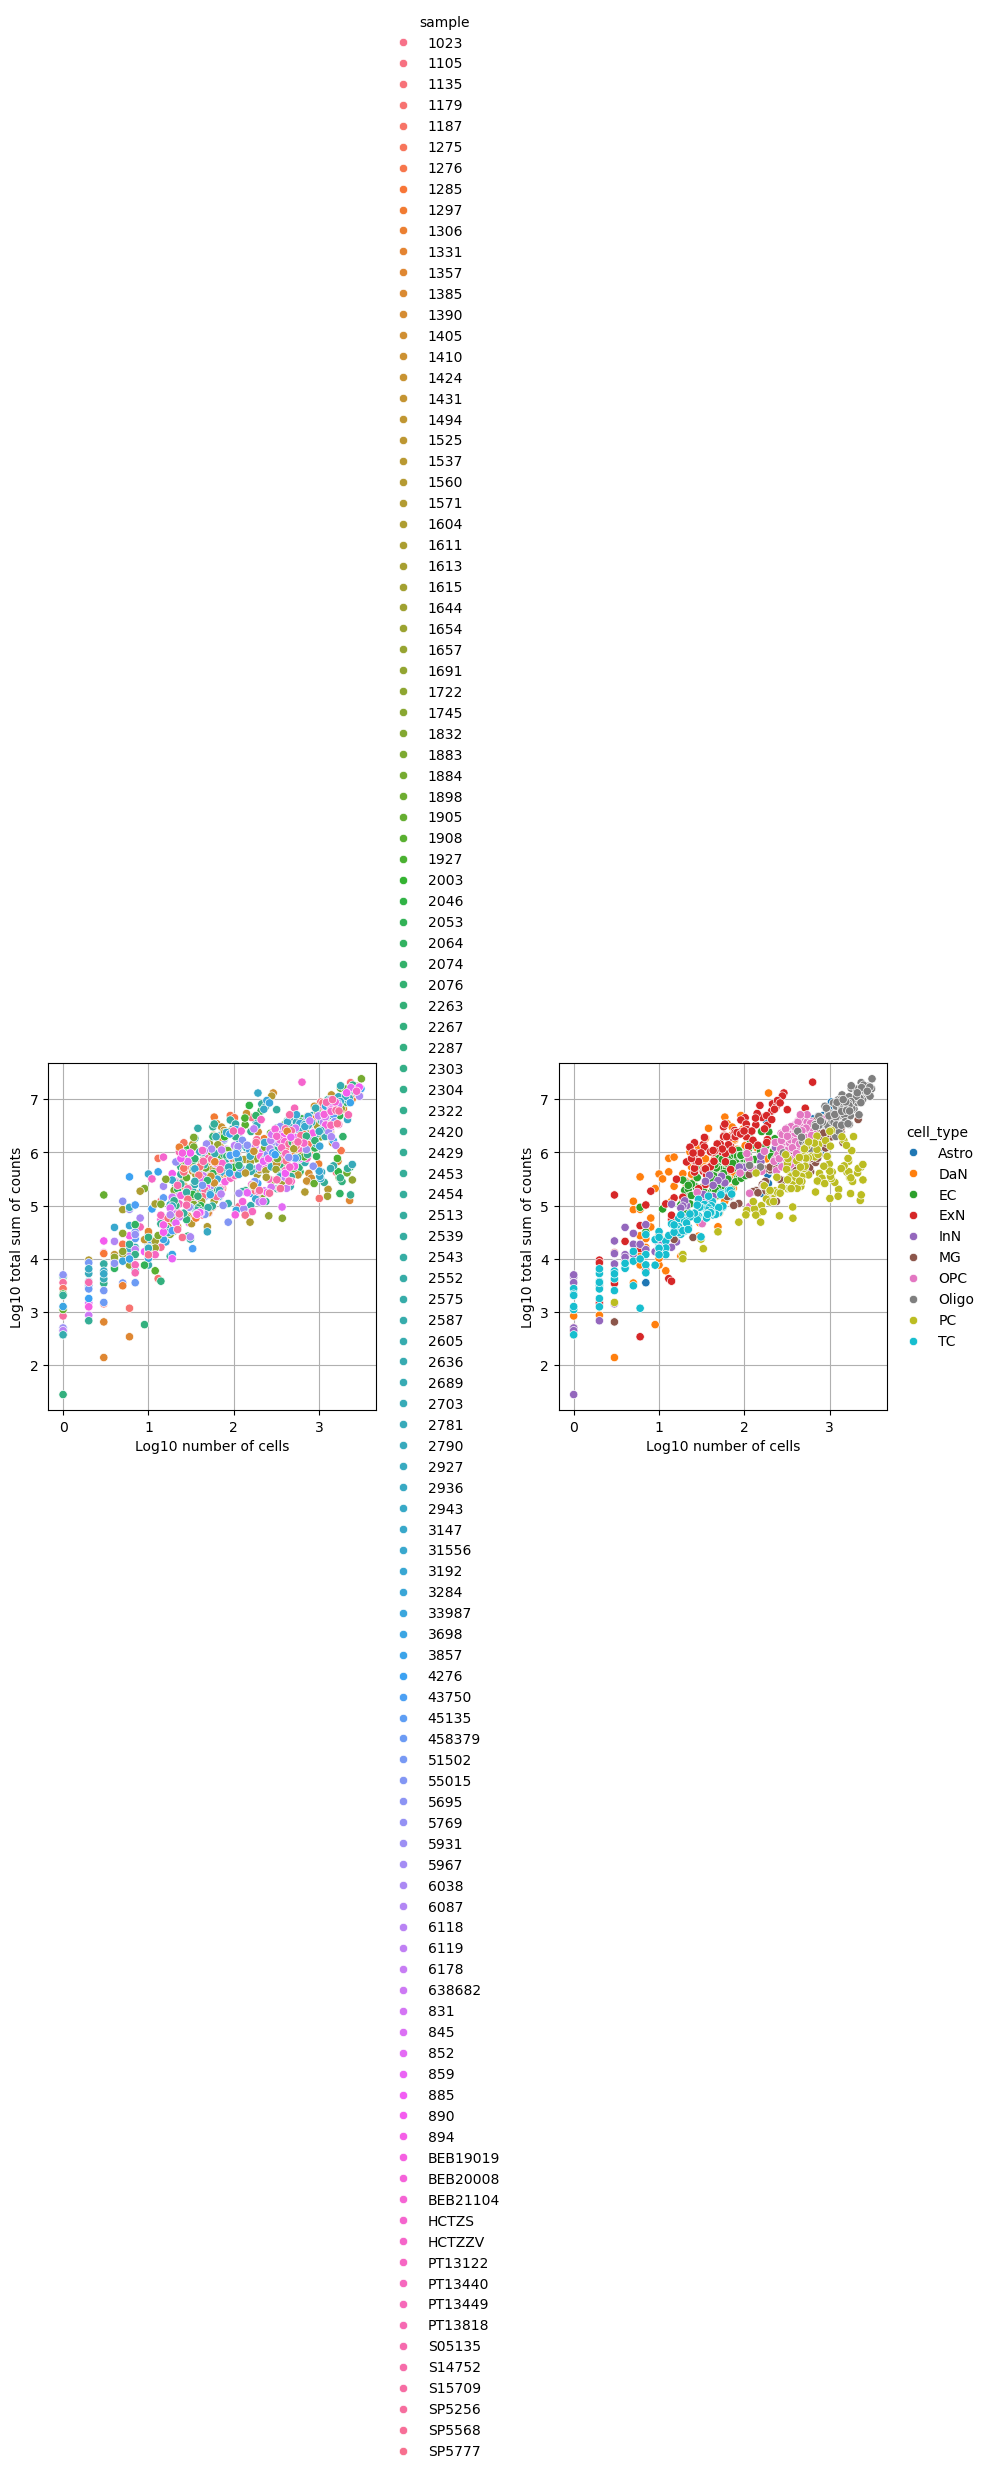

In [21]:
# Define output path 
output_path = 'output/PLOTS/psbulk_samples_pdata_all_pre_filter.png'

# PLOT - QC metrics 
dc.plot_psbulk_samples(
    pdata_all_pre_filter,
    groupby = ['sample', 'cell_type'],
    figsize = (10, 16),
    # legend  = False,
    save    = output_path,
)

print(f'Created file at: {output_path}')

In [22]:
# QC metrics

# Get pseudo-bulk profile - of ALL celltypes, filtered
pdata_all_filtered = dc.get_pseudobulk(
    adata,
    sample_col  = 'sample',
    groups_col  = 'cell_type',
    layer       = 'counts',
    mode        = 'sum',
    min_cells   = 10,
    min_counts  = 10
)

Created file at: output/PLOTS/psbulk_samples_pdata_all_filtered.png


/data/fonge2/conda/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  func(*args, **kwargs)
/data/fonge2/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


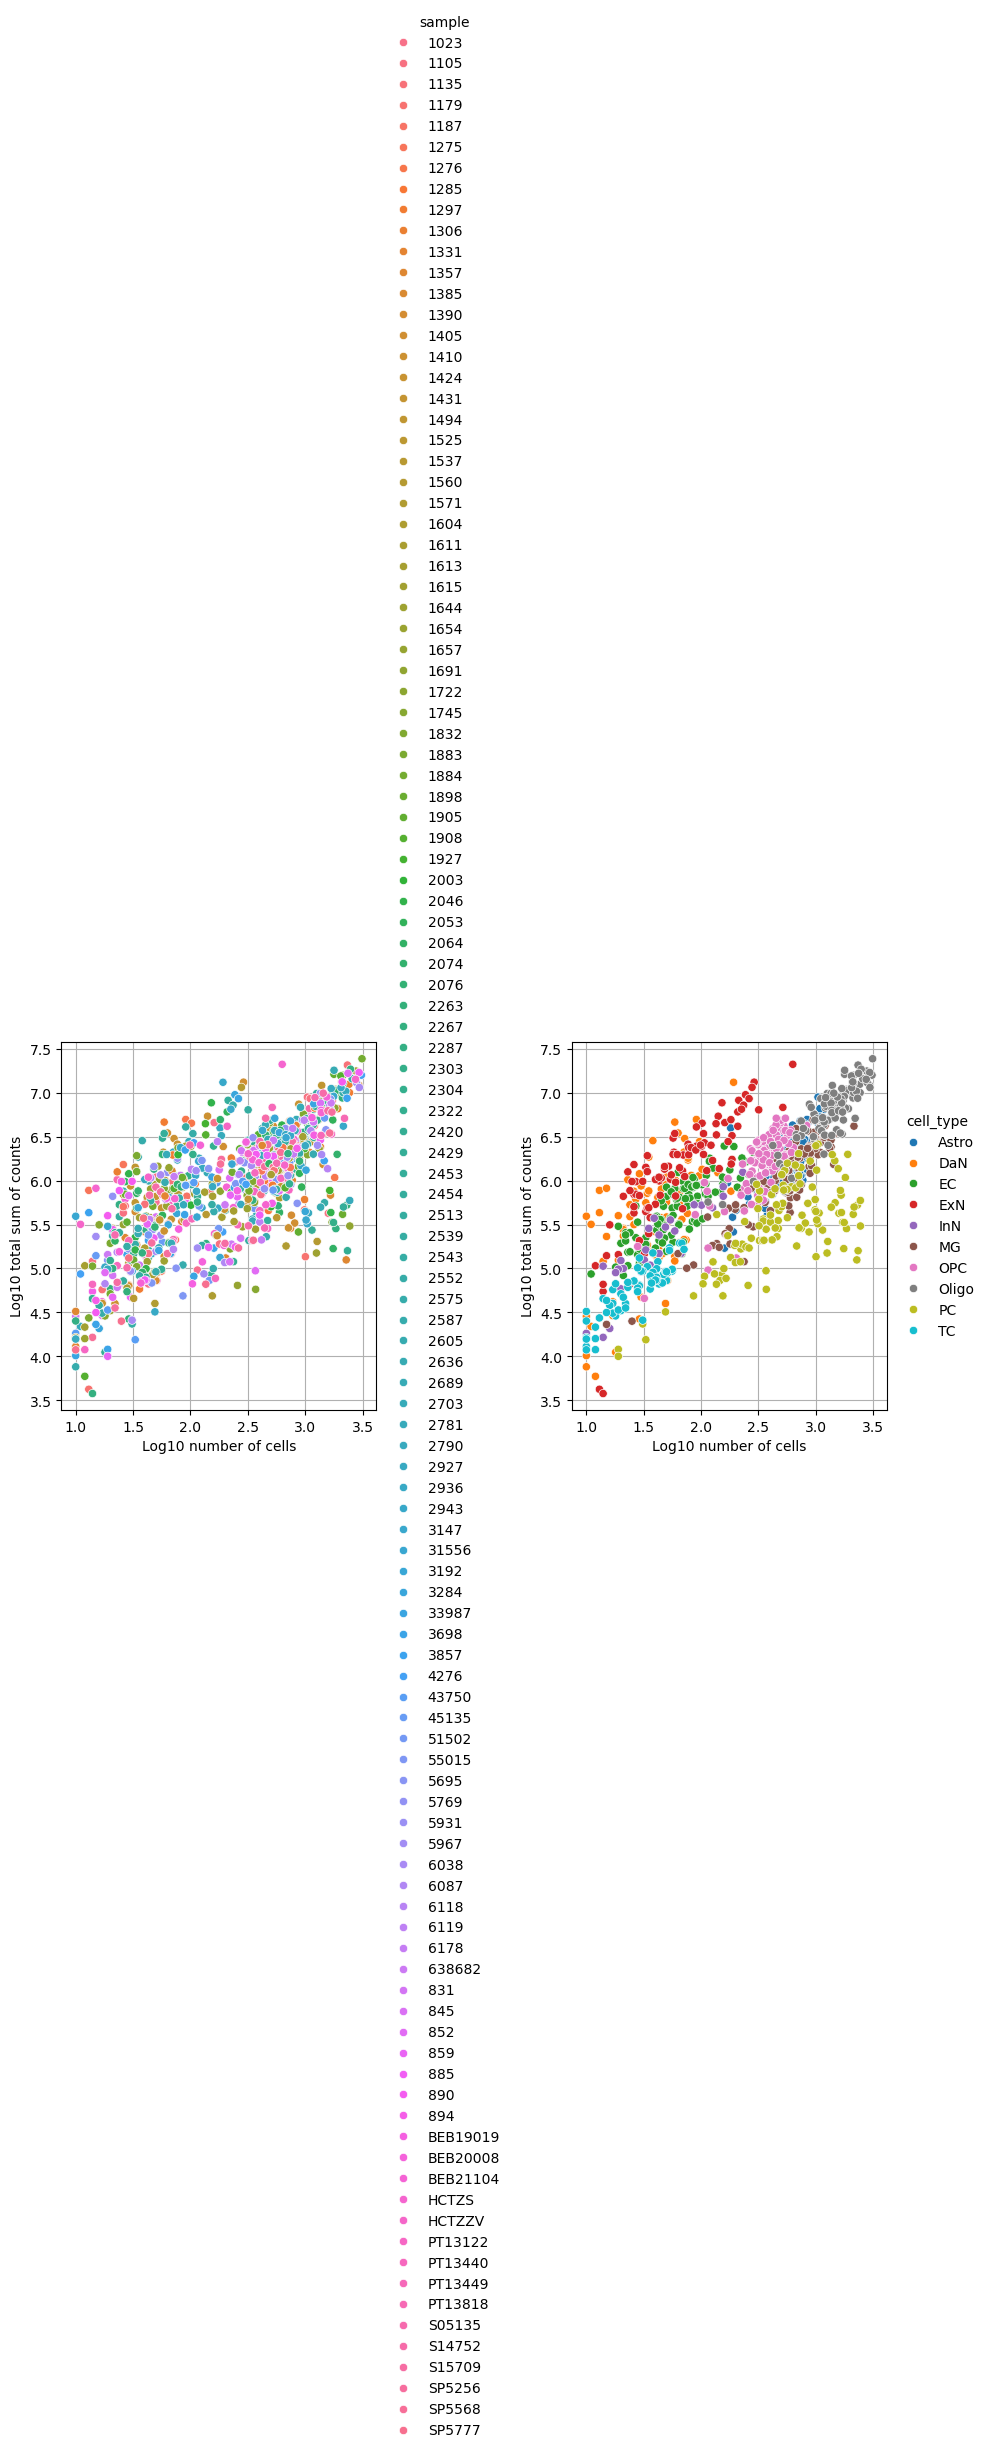

In [23]:
# Define output path 
output_path = 'output/PLOTS/psbulk_samples_pdata_all_filtered.png'

# PLOT - QC metrics 
dc.plot_psbulk_samples(
    pdata_all_filtered,
    groupby = ['sample', 'cell_type'],
    figsize = (10, 16),
    # legend  = False,
    save    = output_path,
)

print(f'Created file at: {output_path}')

In [24]:
# QC metrics

# Get pseudo-bulk profile - of the selected cell type
pdata_pre_filter = dc.get_pseudobulk(
    adata[adata.obs['cell_type'] == selected_cell_type].copy(),
    sample_col  = 'sample',
    groups_col  = 'cell_type',
    layer       = 'counts',
    mode        = 'sum',
    min_cells   = 0,
    min_counts  = 0
)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Created file at: output/PLOTS/psbulk_samples_pdata_pre_filter.png


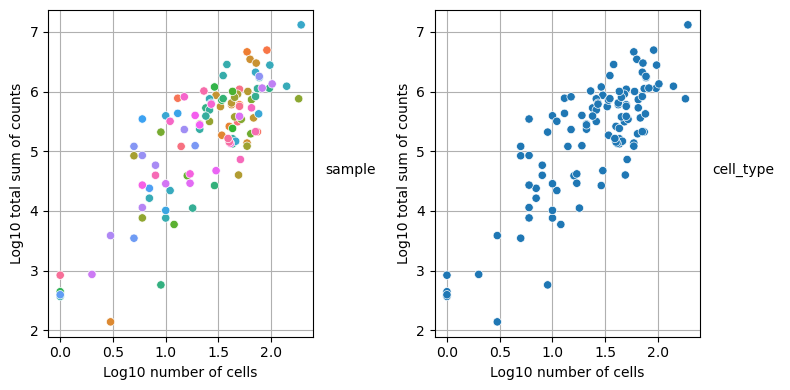

In [25]:
# Define output path 
output_path = 'output/PLOTS/psbulk_samples_pdata_pre_filter.png'

# PLOT - QC metrics
dc.plot_psbulk_samples(
    pdata_pre_filter,
    groupby = ['sample', 'cell_type'],
    figsize = (8, 4),
    legend  = False,
    save    = output_path,
)

print(f'Created file at: {output_path}')

In [26]:
#* TODO - go thru 1 cell type at a time before you make a loop

# Get pseudo-bulk profile
pdata = dc.get_pseudobulk(
    adata[adata.obs['cell_type'] == selected_cell_type].copy(),
    sample_col  = 'sample',
    groups_col  = 'cell_type',
    layer       = 'counts',
    mode        = 'sum',
    min_cells   = 10,
    min_counts  = 10,   # Much lower than the tutorial's rec of 1,000
)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Created file at: output/PLOTS/psbulk_samples_pdata-DaN.png


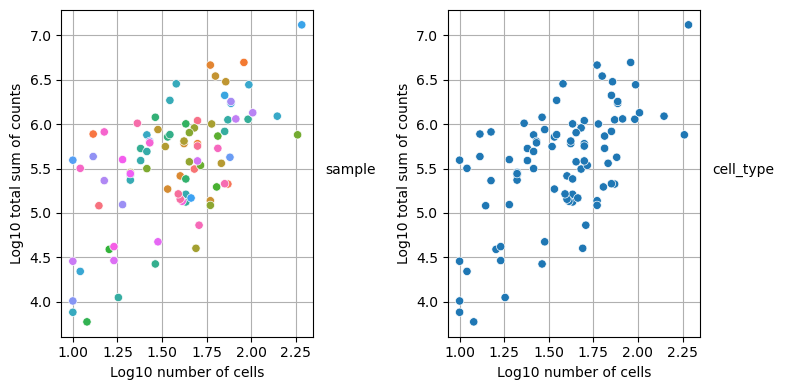

In [27]:
# Define output path 
output_path = f'output/PLOTS/psbulk_samples_pdata-{selected_cell_type}.png'

# PLOT - QC metrics
dc.plot_psbulk_samples(
    pdata,
    groupby = ['sample', 'cell_type'],
    figsize = (8, 4),
    legend  = False,
    save    = output_path,
)

print(f'Created file at: {output_path}')

In [28]:
# CHECK
pdata

AnnData object with n_obs × n_vars = 89 × 31964
    obs: 'sample', 'cell_type', 'batch', 'sex', 'age', 'pmi', 'ethnicity', 'race', 'brain_bank', 'homogenization', 'library', 'seq', 'short diagnosis', 'age_old', 'age_bin', 'psbulk_n_cells', 'psbulk_counts'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mt', 'rb', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'psbulk_props'

In [29]:
# CONVERT - age col into float types
pdata.obs['age'] = pdata.obs.age.astype('float')
pdata.obs['age']

1023_DaN       63.0
1105_DaN       44.2
1135_DaN       60.4
1179_DaN       45.4
1187_DaN       21.5
               ... 
PT13818_DaN    67.0
S05135_DaN     86.0
S14752_DaN     76.0
S15709_DaN     81.0
SP5568_DaN     65.0
Name: age, Length: 89, dtype: float64

# QC PLOTS - on the pseudobulk data by cell type?

In [30]:
# List of pdata files now
pdata_list = [
    'pdata_all_pre_filter',
    'pdata_all_filtered',
    'pdata_pre_filter',
    'pdata'
]

In [31]:
# 

In [32]:
# Store raw counts in layers
pdata.layers['counts'] = pdata.X.copy()
pdata.X.copy()

array([[  4.,   5.,   1., ...,  13., 103.,   0.],
       [  0.,   3.,   0., ...,   2.,   6.,   0.],
       [  0.,   0.,   3., ...,   8.,  42.,   0.],
       ...,
       [  0.,   1.,   0., ...,   4.,  41.,   0.],
       [  0.,   1.,   1., ...,   5.,  20.,   0.],
       [  3.,   1.,   1., ...,   9.,  43.,   0.]], dtype=float32)

In [33]:
# Normalize, scale and compute PCA
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

In [34]:
# Return raw counts to X
dc.swap_layer(
    pdata, 
    'counts', 
    X_layer_key = None, 
    inplace = True
)

# ~~~~~~~~ WIP ~~~~~~~~~

In [ ]:
#CHECK 
pdata

AnnData object with n_obs × n_vars = 89 × 31964
    obs: 'sample', 'cell_type', 'batch', 'sex', 'age', 'pmi', 'ethnicity', 'race', 'brain_bank', 'homogenization', 'library', 'seq', 'short diagnosis', 'age_old', 'age_bin', 'psbulk_n_cells', 'psbulk_counts'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mt', 'rb', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

In [36]:
# GET - all of the col names
# - drop the 'sample' col [col #0] tho, that doesn't work
color = pdata.obs.columns.to_list()[1:]
color

['cell_type',
 'batch',
 'sex',
 'age',
 'pmi',
 'ethnicity',
 'race',
 'brain_bank',
 'homogenization',
 'library',
 'seq',
 'short diagnosis',
 'age_old',
 'age_bin',
 'psbulk_n_cells',
 'psbulk_counts']

In [37]:
# # TEST -- ughhhh I might have to do all of the norm/log2p/scale/pca steps again ???
# # NOTE - `color = []` section needs to be from the adata.obs cols, but for pdata it doesn't work on the `sample` col either, not sure why tho

# # NOTE - try all these on the regular pdata file 1st


# # PLOT - UMAP of the pseudo-bulk data, comparing select conditions
# sc.pl.pca(
#     pdata,
#     color   = ['cell_type', 'batch', 'sex', 'age', 'pmi', 'ethnicity', 'race', 'brain_bank', 'homogenization', 'library', 'seq', 'short diagnosis', 'age_old', 'age_bin', 'psbulk_n_cells', 'psbulk_counts'],
#     # color   = color,
#     ncols   = 3,
#     size    = 300,  # Point size
#     wspace  = 0.3,  # Width space between plots     
#     # save =
# )

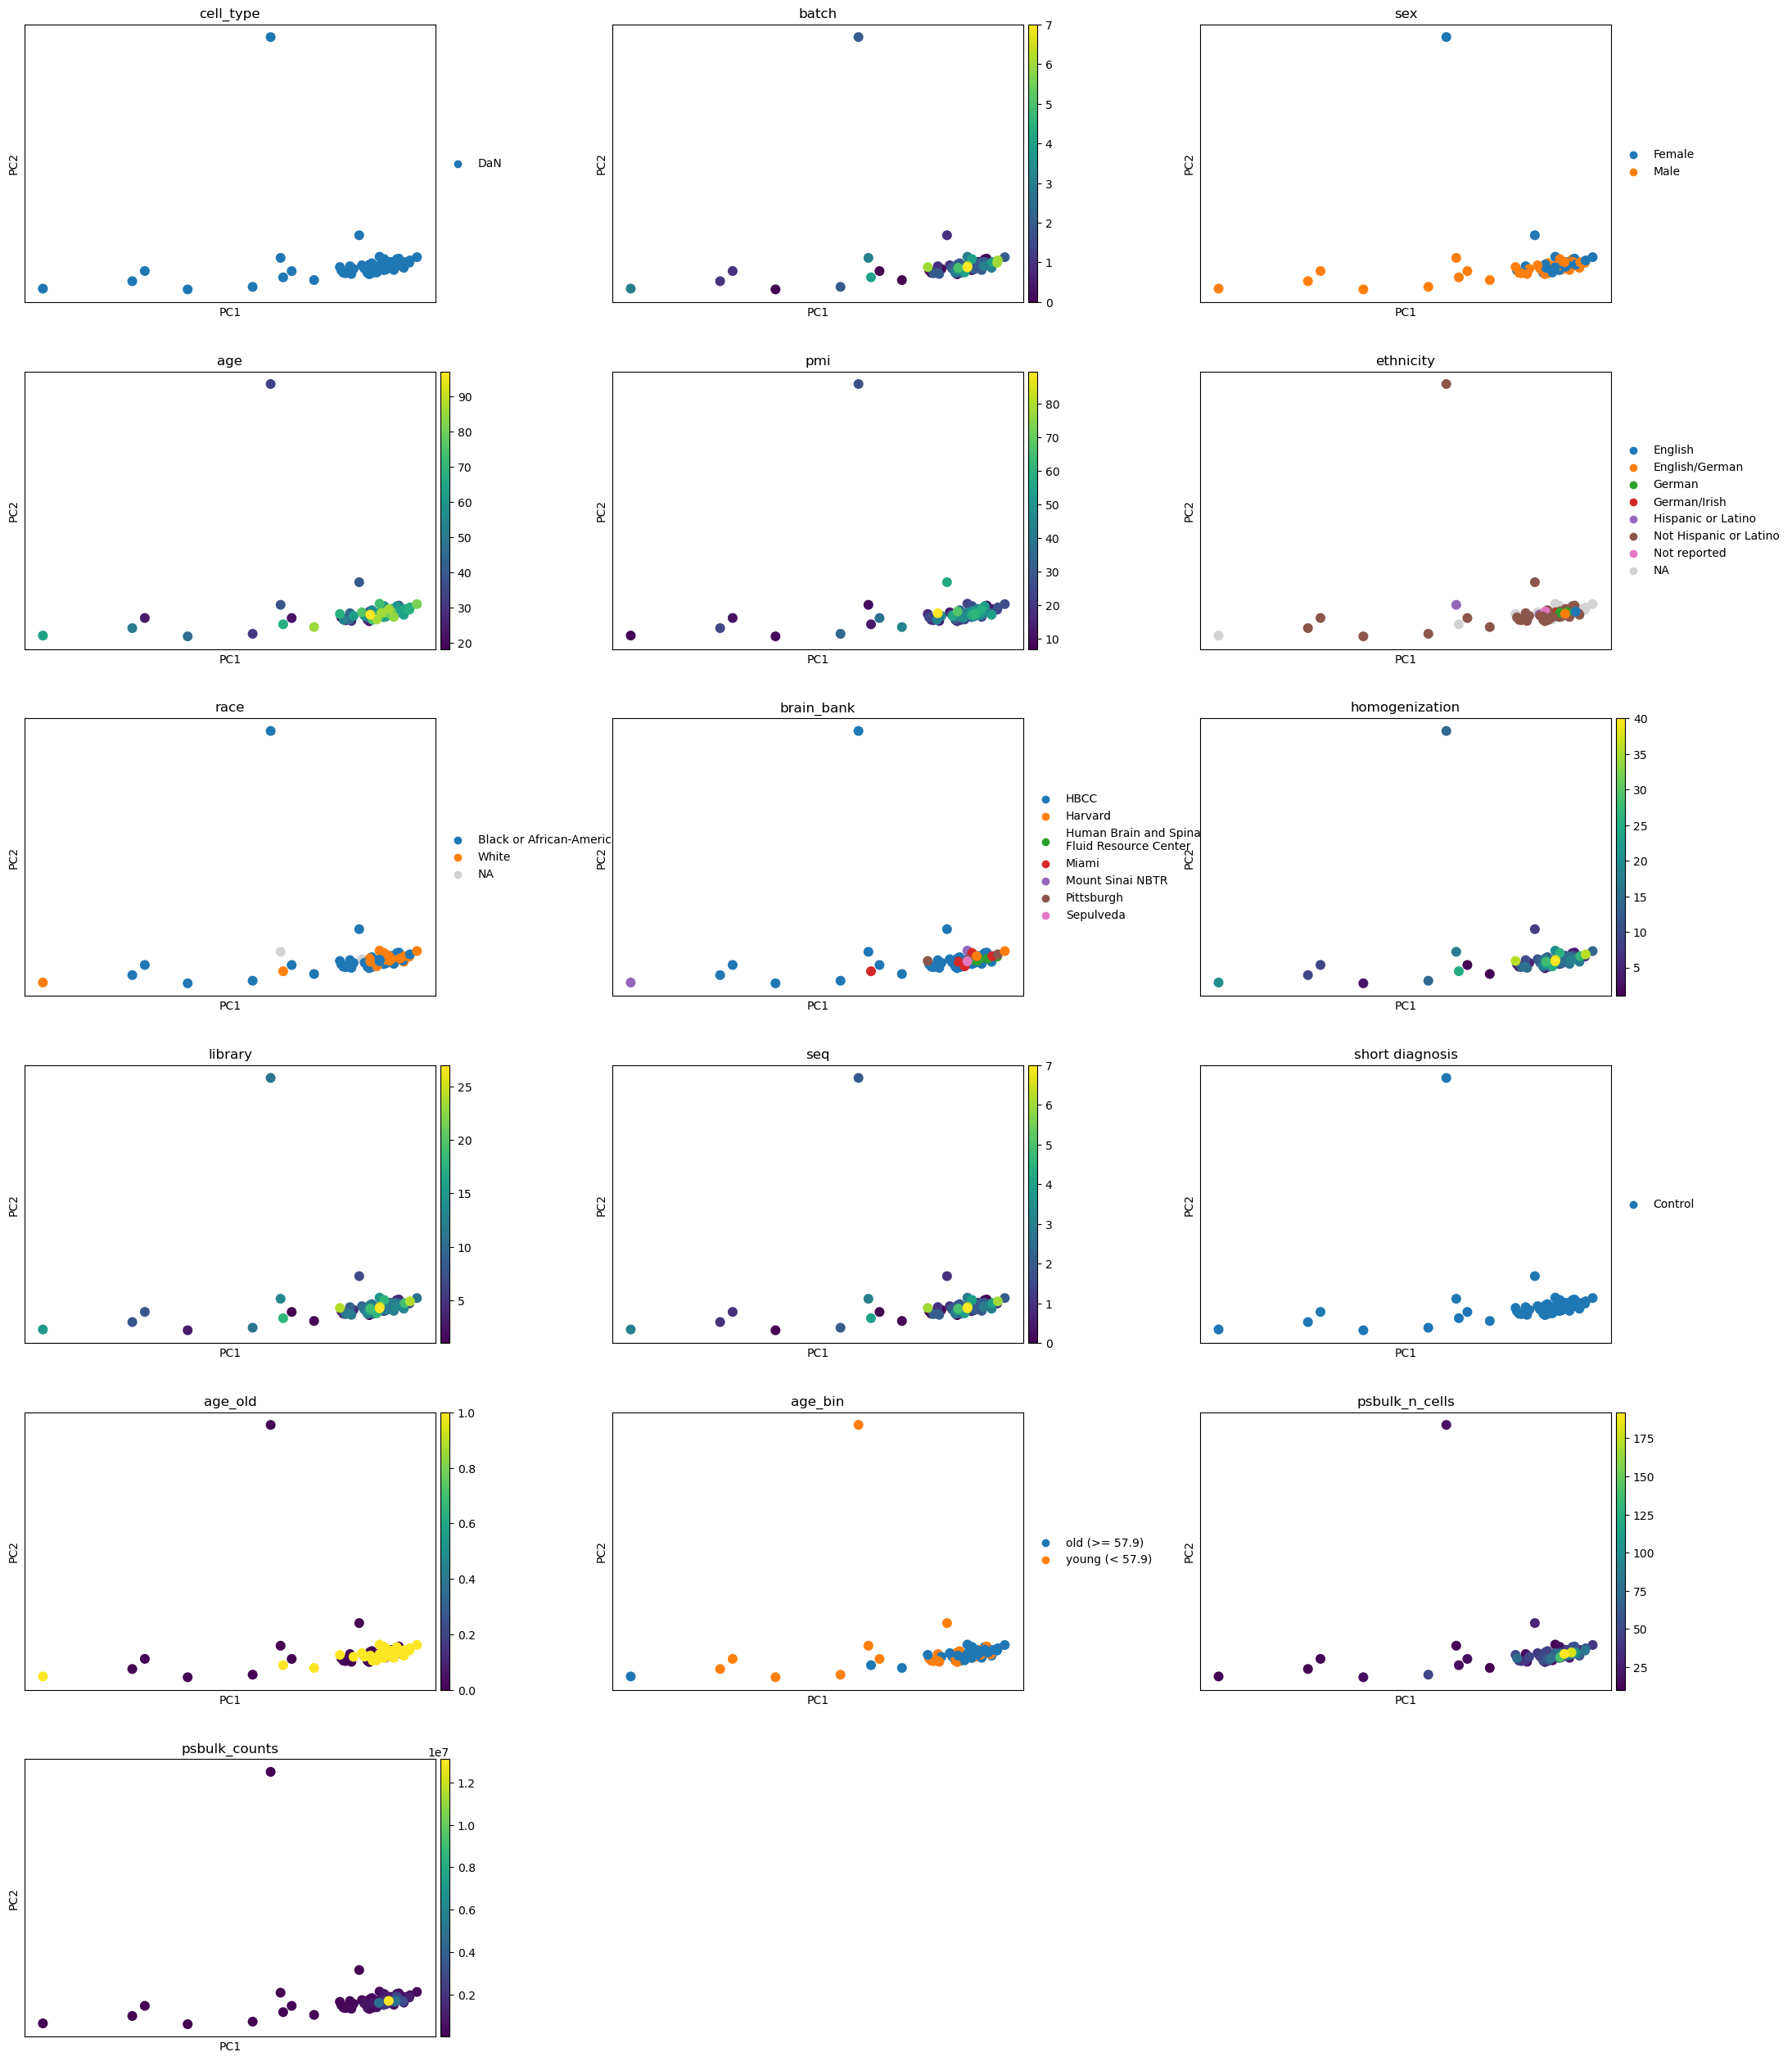

Created file at: output/PLOTS/psbulk_samples_pdata-DaN.png
len(color) = 16


In [38]:
# Define output path 
output_file = '-ps_pdata_PCA.png'
# print('output_file =', output_file)

# PLOT - UMAP of the PCs
sc.pl.pca(
    pdata,
    color   = color,
    ncols   = 3,
    size    = 300,  
    wspace  = 0.3,
    save    = output_file,
    )
print(f'Created file at: {output_path}')

# CHECK
print('len(color) =', len(color))

In [39]:
# # Define output path 
# output_path = 'output/PLOTS/ps_pdata_PCA.png'

# # TRY - to plot UMAP of the PCs, expecting an error to be thrown up
# try:
#     # my_plot = eval("sc.pl.pca(pdata, color = color, ncols = 3, size = 300, wspace = 0.3)")
    
#     sc.pl.pca(
#         pdata,
#         color   = color,
#         ncols   = 3,
#         size    = 300,  
#         wspace  = 0.3,
#         save    = output_path,
#         )
#     print(f'Created file at: {output_path}')

# # ERROR - take the error message as string and remove those elements from the color list so it can plot properly
# except Exception as e:
#     error_message = str(e)
#     print('error_message =', error_message)
    
#     error_split = re.split(r'Could not find key| in ', error_message)
#     print('error_split =', error_split)
    
#     if len(error_split) > 1:
#         to_remove = error_split[1].strip()
#         print('to_remove: ', to_remove)
        
#         if to_remove in color:
#             print('current len(color) =', len(color))
#             color.remove(to_remove)
#             print('new len(color) =', len(color))
            
#         else:
#             print('to_remove is NOT in color')
            
#         print('Edited list: \ncolor = ', color)
        
#     else:
#         print('Error message format not recognized:', error_message)

# # CHECK
# print('new len(color) =', len(color))
# print('Final edited list: \ncolor =', color)

# #* TODO - rerun until there are no more errors!

### NOTES

SUMMARY: most of it clusters together in the big cluster on the right
- Sex:          males on left
- Age:          older on right
- PMI:          longer hrs on right, shorter hrs on left
- Race:         Black/African-American on left
- Brain Bank:   HBCC some on left

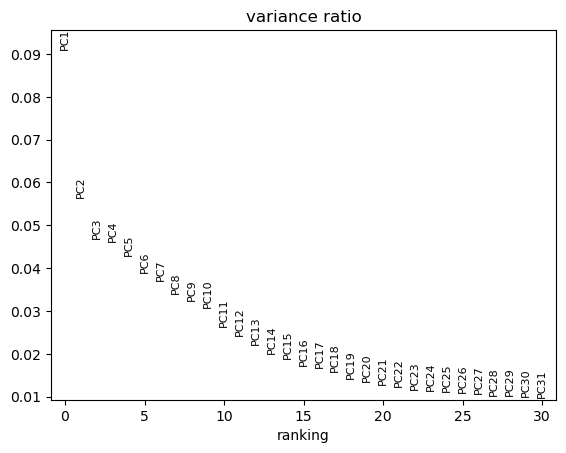

In [40]:
sc.pl.pca_variance_ratio(pdata)

In [41]:
# # RENAME - col names with a space in the name will be problematic
# # Abreviate diagnosis
# pdata.obs['diagnosis'] = pdata.obs['Primary Diagnosis']

In [42]:
# NORMALIZE - ages and shift the center to 0 so positive #'s = old, negative #'s = young
ages = pdata.obs.age

#? Q) What is this doing?
#? A) Normalizing the ages to be 0 - 1, and then shifting the center to 0 so the range is now -0.5 to 0.5
#?    Then the old = positive #'s and the young = negative #'s
pdata.obs['normalage'] = (ages - np.min(ages)) / (np.max(ages) - np.min(ages)) - 0.5

# # CHECK
# print('ages = \n', ages, '\n')
# print('np.min(ages) =', np.min(ages))
# print('np.max(ages) =', np.max(ages))
# print('np.max(ages) - np.min(ages) =', np.max(ages) - np.min(ages))

In [43]:
# CHECK
print(pdata.obs.columns)

Index(['sample', 'cell_type', 'batch', 'sex', 'age', 'pmi', 'ethnicity',
       'race', 'brain_bank', 'homogenization', 'library', 'seq',
       'short diagnosis', 'age_old', 'age_bin', 'psbulk_n_cells',
       'psbulk_counts', 'normalage'],
      dtype='object')


In [44]:
# # FIX - space in name
# pdata.obs['short_diagnosis'] = pdata.obs['short diagnosis']

In [45]:
#* TODO - check up what this command is doing

dc.get_metadata_associations(
    pdata,
    obs_keys = [
        'normalage', 
        # 'short_diagnosis', 
        'age_bin',
        'psbulk_n_cells', 
        'psbulk_counts'
        ],                      # Metadata columns to associate to PCs
    obsm_key    = 'X_pca',      # Where the PCs are stored
    uns_key     = 'pca_anova',  # Where the results are stored
    inplace     = True,
)

In [46]:
# CHECK
pdata

AnnData object with n_obs × n_vars = 89 × 31964
    obs: 'sample', 'cell_type', 'batch', 'sex', 'age', 'pmi', 'ethnicity', 'race', 'brain_bank', 'homogenization', 'library', 'seq', 'short diagnosis', 'age_old', 'age_bin', 'psbulk_n_cells', 'psbulk_counts', 'normalage'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mt', 'rb', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'log1p', 'pca', 'cell_type_colors', 'sex_colors', 'ethnicity_colors', 'race_colors', 'brain_bank_colors', 'short diagnosis_colors', 'age_bin_colors', 'pca_anova'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

In [47]:
# NOTE - i'm not using this col
# pdata.obs.short_diagnosis

In [48]:
# FILTER - genes with low expression
pdata_genes = dc.filter_by_expr(
    pdata, 
    # group           = 'diagnosis', 
    # group           = 'short_diagnosis', 
    group           = 'age_bin',
    min_count       = 10, 
    min_total_count = 15
    )

# CHECK
pdata_genes

array(['AACS', 'AAGAB', 'AAK1', ..., 'ZXDC', 'ZYG11B', 'ZZEF1'],
      dtype='<U17')

In [49]:
# CHECK
pdata[:, pdata_genes]

View of AnnData object with n_obs × n_vars = 89 × 6122
    obs: 'sample', 'cell_type', 'batch', 'sex', 'age', 'pmi', 'ethnicity', 'race', 'brain_bank', 'homogenization', 'library', 'seq', 'short diagnosis', 'age_old', 'age_bin', 'psbulk_n_cells', 'psbulk_counts', 'normalage'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mt', 'rb', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'log1p', 'pca', 'cell_type_colors', 'sex_colors', 'ethnicity_colors', 'race_colors', 'brain_bank_colors', 'short diagnosis_colors', 'age_bin_colors', 'pca_anova'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

In [50]:
pdata = pdata[:, pdata_genes].copy()
pdata

AnnData object with n_obs × n_vars = 89 × 6122
    obs: 'sample', 'cell_type', 'batch', 'sex', 'age', 'pmi', 'ethnicity', 'race', 'brain_bank', 'homogenization', 'library', 'seq', 'short diagnosis', 'age_old', 'age_bin', 'psbulk_n_cells', 'psbulk_counts', 'normalage'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mt', 'rb', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'log1p', 'pca', 'cell_type_colors', 'sex_colors', 'ethnicity_colors', 'race_colors', 'brain_bank_colors', 'short diagnosis_colors', 'age_bin_colors', 'pca_anova'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

In [51]:
#? Q) Is it ok to have normalage and age_bin in the design_factors?
#? A) nooooooo, both are looking at a similar stat

inference = DefaultInference(n_cpus=8)

dds = DeseqDataSet(
    adata           = pdata[pdata.obs['cell_type'] == selected_cell_type].copy(),
    design_factors  = ['age_bin', 'batch'],
    refit_cooks     = True,
    inference       = inference,
)

# Compute LFCs
dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


/tmp/ipykernel_3206530/350292461.py:6: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.84 seconds.

Fitting dispersion trend curve...
/data/fonge2/conda/lib/python3.10/site-packages/pydeseq2/dds.py:804: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.10 seconds.

Fitting MAP dispersions...
... done in 0.78 seconds.

Fitting LFCs...
... done in 0.55 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 213 outlier genes.

Fitting dispersions...
... done in 0.05 seconds.

Fitting MAP dispersions...
... done in 0.04 seconds.

Fitting LFCs...
... done in 0.04 seconds.



In [52]:
# EXTRACT - contrast between young and old
stat_res = DeseqStats(
    dds,
    contrast    = ["age_bin", young[0] , old[0] ],
    inference   = inference,
)

In [53]:
# Compute Wald test
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: age_bin young (< 57.9) vs old (>= 57.9)
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AACS     14.304684       -0.022569  0.105123 -0.214689  0.830010  0.975029
AAGAB    16.056164       -0.001291  0.115338 -0.011195  0.991068  0.997333
AAK1    114.834743       -0.102231  0.071120 -1.437444  0.150592  0.677513
AARS     18.340447        0.003249  0.147285  0.022057  0.982402  0.995252
AARSD1    9.694544        0.125858  0.149122  0.843994  0.398673       NaN
...            ...             ...       ...       ...       ...       ...
ZUP1      7.818206        0.139048  0.132814  1.046940  0.295127       NaN
ZW10      8.821378        0.370891  0.124247  2.985100  0.002835       NaN
ZXDC     17.317768       -0.133123  0.099828 -1.333531  0.182358  0.701100
ZYG11B   27.167553       -0.103215  0.095287 -1.083200  0.278720  0.784746
ZZEF1    38.621339       -0.097606  0.139702 -0.698676  0.484755  0.884246

[6122 rows x 6 column

... done in 0.44 seconds.



In [54]:
# EXTRACT - results to DF
DGE_results_df = stat_res.results_df

# Add a celltype col
DGE_results_df['cell_type'] = selected_cell_type

# CHECK
DGE_results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,cell_type
AACS,14.304684,-0.022569,0.105123,-0.214689,0.830010,0.975029,DaN
AAGAB,16.056164,-0.001291,0.115338,-0.011195,0.991068,0.997333,DaN
AAK1,114.834743,-0.102231,0.071120,-1.437444,0.150592,0.677513,DaN
AARS,18.340447,0.003249,0.147285,0.022057,0.982402,0.995252,DaN
AARSD1,9.694544,0.125858,0.149122,0.843994,0.398673,NaN,DaN
...,...,...,...,...,...,...,...
ZUP1,7.818206,0.139048,0.132814,1.046940,0.295127,NaN,DaN
ZW10,8.821378,0.370891,0.124247,2.985100,0.002835,NaN,DaN
ZXDC,17.317768,-0.133123,0.099828,-1.333531,0.182358,0.701100,DaN
ZYG11B,27.167553,-0.103215,0.095287,-1.083200,0.278720,0.784746,DaN


In [55]:
#? Q) What is this doing?
# - Creating a new col based on the negative log 10 of padj???
# NOTE: negative log₁₀ values represent increasingly smaller decimal numbers. Each decrease by 1 in the negative log₁₀ represents dividing by 10
DGE_results_df['-log10_padj'] = -np.log10(DGE_results_df['padj'])
DGE_results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,cell_type,-log10_padj
AACS,14.304684,-0.022569,0.105123,-0.214689,0.830010,0.975029,DaN,0.010982
AAGAB,16.056164,-0.001291,0.115338,-0.011195,0.991068,0.997333,DaN,0.001160
AAK1,114.834743,-0.102231,0.071120,-1.437444,0.150592,0.677513,DaN,0.169082
AARS,18.340447,0.003249,0.147285,0.022057,0.982402,0.995252,DaN,0.002067
AARSD1,9.694544,0.125858,0.149122,0.843994,0.398673,NaN,DaN,NaN
...,...,...,...,...,...,...,...,...
ZUP1,7.818206,0.139048,0.132814,1.046940,0.295127,NaN,DaN,NaN
ZW10,8.821378,0.370891,0.124247,2.985100,0.002835,NaN,DaN,NaN
ZXDC,17.317768,-0.133123,0.099828,-1.333531,0.182358,0.701100,DaN,0.154220
ZYG11B,27.167553,-0.103215,0.095287,-1.083200,0.278720,0.784746,DaN,0.105271


In [56]:
# # EXTRACT - only genes that passed the sig threshold

# # Filter rows based on column: '-log10_padj'
# DGE_results_df_pval = DGE_results_df[DGE_results_df['-log10_padj'] > 2]

# # Filter rows based on column: 'log2FoldChange'
# DGE_results_df_pval_l2fc = DGE_results_df_pval[DGE_results_df_pval['log2FoldChange'] > 1]

# # Order by column: '-log10_padj' (descending)
# DGE_results_df_pval_l2fc_sorted = DGE_results_df_pval_l2fc.sort_values(['-log10_padj'], ascending=[False])
# DGE_results_df_pval_l2fc_sorted

In [57]:
# EXTRACT - only genes that passed the sig threshold
# SUMMARY: Filter and sort DGE results
# Filter rows based on column: '-log10_padj'
# Filter rows based on column: 'log2FoldChange'
# Order by column: '-log10_padj' (descending)
DGE_results_df_pval_l2fc_sorted = (
    DGE_results_df[(DGE_results_df['-log10_padj'] > 2) & 
                   (DGE_results_df['log2FoldChange'] > 1)]
    .sort_values(['-log10_padj'], ascending=[False])
)
DGE_results_df_pval_l2fc_sorted

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,cell_type,-log10_padj
LINC02150,13.064907,1.4111,0.273005,5.16877,2.356395e-07,0.001163,DaN,2.934465


# EXPORT - results

### .CSV version

In [58]:
# # # DGE_results_df.to_csv(snakemake.output.output_figure)
# output_path = os.path.join(f'output/DGE_results_df-{selected_cell_type}.csv')
# DGE_results_df.to_csv(output_path)
# print(f'Created file at: {output_path}')

In [59]:
# # EXPORT - DF of results passing thresholds to CSV
# output_path = f'output/DGE_results_df-{selected_cell_type}-pval_l2fc_sorted.csv'
# DGE_results_df_pval_l2fc_sorted.to_csv(output_path, index=False)
# print(f'Created file at: {output_path}')

#* TODO - rerun as .TSV eventually

### .TSV version

In [60]:
# # DGE_results_df.to_csv(snakemake.output.output_figure)
output_path = os.path.join(f'output/DGE_results_df-{selected_cell_type}.tsv')
DGE_results_df.to_csv(output_path, sep='\t')
print(f'Created file at: {output_path}')

Created file at: output/DGE_results_df-DaN.tsv


In [61]:
# Define an output path
output_path = f'output/DGE_results_df-pass_thresholds/DGE_results_df-{selected_cell_type}-pval_l2fc_sorted.tsv'

# Call function to check for or create that path to the output file location
my_makedirs(output_path)

# EXPORT - DF of results passing thresholds to TSV
DGE_results_df_pval_l2fc_sorted.to_csv(output_path, sep='\t')
print(f'Created file at: {output_path}')

'/output/DGE_results_df-pass_thresholds' folder is already there
Created file at: output/DGE_results_df-pass_thresholds/DGE_results_df-DaN-pval_l2fc_sorted.tsv


In [62]:
# EXTRACT - ONLY the index column as a list
index_list = DGE_results_df_pval_l2fc_sorted.index.tolist()
print('index_list =', index_list)

index_list = ['LINC02150']


#* TODO - check up lists on Web Gestalt 

# PLOT(S)

'/output/PLOTS' folder is already there
Created file at: output/PLOTS/volcano_plot-DaN.png


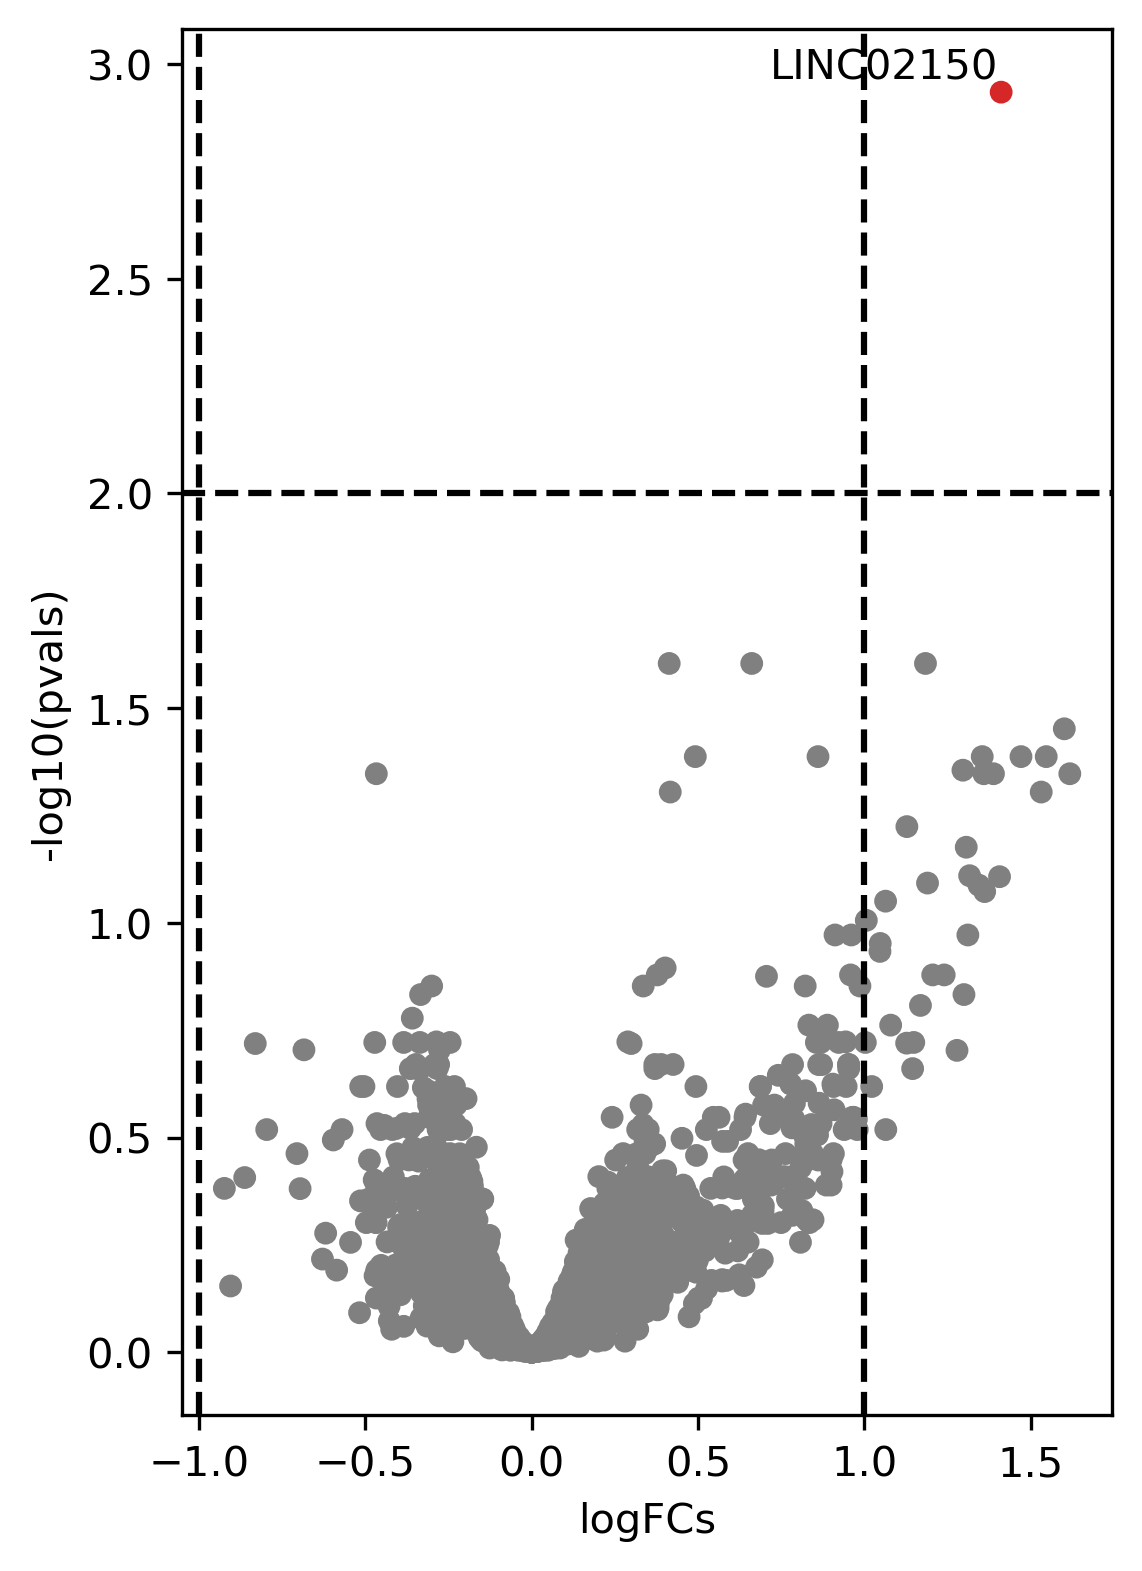

In [63]:
# Define an output path
output_path = f'output/PLOTS/volcano_plot-{selected_cell_type}.png'

# Call function to check for or create that path to the output file location
my_makedirs(output_path)

# PLOT - volcano plot 
dc.plot_volcano_df(
    DGE_results_df,
    x           = 'log2FoldChange',
    y           = 'padj',   # Pvals = significance?
    top         = 20,       # Top N hits to label
    lFCs_thr    = 1,        # Log2 fold change threshold = magnitude?
    sign_thr    = 1e-2,     # Significance threshold
    figsize     = (4, 6),
    dpi         = 300,
    save        = output_path
)
print(f'Created file at: {output_path}')

#* TODO - run the other celltypes by making a separate JNB for each so we can explore the results